In [ ]:
import pathlib

In [ ]:
import marimo as mo
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [ ]:
from conduitpylib.wrangle import (
    find_treat_idx_mapped_col,
    retrieve_and_prepare_delta_dataframes,
)

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-09-13T04:22:58.935036+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1064-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

seaborn   : 0.13.2
scipy     : 1.14.1
teeplot   : 1.4.2
pandas    : 2.2.3
requests  : 2.34.2
marimo    : 0.23.2
matplotlib: 3.9.2
numpy     : 2.1.2

```

## Prep Data

In [ ]:
for slug in "jgpnv", "ncdfq":
    with open(f"/tmp/{slug}", "wb") as _fp:
        _fp.write(
            requests.get(
                f"https://osf.io/{slug}/download", allow_redirects=True
            ).content,
        )

merge_df, (
    _df_finalized_observations,
    df_snapshot_diffs,
) = retrieve_and_prepare_delta_dataframes(
    df_inlet_url="/tmp/jgpnv",
    df_outlet_url="/tmp/ncdfq",
    treatment_column="Allocation",
    return_merge_df=True,
)

df_snapshot_diffs["Delivery Clumpiness"] = 1 - (
    df_snapshot_diffs["Num Pulls That Were Laden Immediately"]
    / np.minimum(
        df_snapshot_diffs["Num Pulls Attempted"],
        df_snapshot_diffs["Net Flux Through Duct"],
    )
)

allocation_idx_mapped_title = find_treat_idx_mapped_col(df_snapshot_diffs)
allocation_idx_mapped_title

a: df_inlet
digest: 0a67179718d03240e90c2558d41c387ea98478bb3fcd462644ca985a860057e5
num cols: 45
num cols all na: 2
num cols any na: 2
num na: 133120
num rows: 66560
num rows all na: 0
num rows any na: 66560
size: 62M

a: df_outlet
digest: 98595207b6985f49ec331d78584c44aa98ef333032fa410f79c3b8306cbcfcb6
num cols: 71
num cols all na: 6
num cols any na: 6
num na: 399360
num rows: 66560
num rows all na: 0
num rows any na: 66560
size: 75M



'0 = Sans lac-417 | 1 = With lac-417'

In [ ]:
df_snapshot_diffs

<marimo-callout-output data-html='"<span class=\"markdown prose dark:prose-invert contents\"><span class=\"paragraph\"><span class=\"text-error\"><strong>Your output is too large</strong></span></span>\n<span class=\"paragraph\">Your output is too large for marimo to show. It has a size\nof 41143804 bytes. Did you output this object by accident?</span>\n<span class=\"paragraph\">If this limitation is a problem for you, you can configure\nthe max output size by adding (eg)</span>\n<div class=\"language-ini codehilite\"><pre><span></span><code><span class=\"k\">[tool.marimo.runtime]</span>\n<span class=\"na\">output_max_bytes</span><span class=\"w\"> </span><span class=\"o\">=</span><span class=\"w\"> </span><span class=\"s\">10_000_000</span>\n</code></pre></div>\n<span class=\"paragraph\">to your pyproject.toml, or with the environment variable\n<code>MARIMO_OUTPUT_MAX_BYTES</code>:</span>\n<div class=\"language-gdscript codehilite\"><pre><span></span><code><span class=\"k\">export</span><span class=\"w\"> </span><span class=\"n\">MARIMO_OUTPUT_MAX_BYTES</span><span class=\"o\">=</span><span class=\"mi\">10</span><span class=\"n\">_000_000</span>\n</code></pre></div>\n<span class=\"paragraph\">Increasing the max output size may cause performance issues.\nIf you run into problems, please reach out\nto us on <a href=\"https://marimo.io/discord?ref=app\" rel=\"noopener noreferrer\" target=\"_blank\">Discord</a> or\n<a href=\"https://github.com/marimo-team/marimo/issues\" rel=\"noopener noreferrer\" target=\"_blank\">GitHub</a>.</span></span>"' data-kind='"warn"'>

In [ ]:
df_snapshot_diffs[
    ~np.isfinite(df_snapshot_diffs["Latency Simsteps Outlet"])
    | ~np.isfinite(df_snapshot_diffs["Latency Simsteps Inlet"])
    | ~np.isfinite(df_snapshot_diffs["Delivery Failure Rate"])
    | ~np.isfinite(df_snapshot_diffs["Delivery Clumpiness"])
    | ~np.isfinite(df_snapshot_diffs["Simstep Period Outlet (ns)"])
    | ~np.isfinite(df_snapshot_diffs["Simstep Period Inlet (ns)"])
    | ~np.isfinite(df_snapshot_diffs["Latency Walltime Inlet (ns)"])
    | ~np.isfinite(df_snapshot_diffs["Latency Walltime Outlet (ns)"])
][
    [
        "Latency Simsteps Inlet",
        "Latency Simsteps Outlet",
        "Snapshot",
        "Runtime Seconds Elapsed Outlet",
        "Hostname",
        "Replicate",
        "Num Simels Per Cpu",
        "Cpus Per Node",
        "Num Processes",
    ]
]

,Latency Simsteps Inlet,Latency Simsteps Outlet,Snapshot,Runtime Seconds Elapsed Outlet,Hostname,Replicate,Num Simels Per Cpu,Cpus Per Node,Num Processes


In [ ]:
df_snapshot_diffs["Simstep Period Inlet (ms)"] = (
    df_snapshot_diffs["Simstep Period Inlet (ns)"] / 10**6
)
df_snapshot_diffs["Latency Walltime Inlet (ms)"] = (
    df_snapshot_diffs["Latency Walltime Inlet (ns)"] / 10**6
)
df_snapshot_diffs["Simstep Period Outlet (ms)"] = (
    df_snapshot_diffs["Simstep Period Outlet (ns)"] / 10**6
)
df_snapshot_diffs["Latency Walltime Outlet (ms)"] = (
    df_snapshot_diffs["Latency Walltime Outlet (ns)"] / 10**6
)

In [ ]:
data_mean = (
    df_snapshot_diffs.copy()
    .groupby(
        [
            "Execution Instance UUID",
        ]
    )
    .mean(numeric_only=True)
    .reset_index()
    .astype(
        {
            "Num Processes": "int64",
            "Allocated Tasks Per Node": "int64",
            "Cpus Per Node": "int64",
            "Num Simels Per Cpu": "int64",
            allocation_idx_mapped_title: "int64",
        }
    )[
        [
            allocation_idx_mapped_title,
            "Latency Simsteps Outlet",
            # "Latency Simsteps Inlet",
            "Delivery Failure Rate",
            "Delivery Clumpiness",
            "Simstep Period Outlet (ms)",
            # "Simstep Period Inlet (ms)",
            "Latency Walltime Outlet (ms)",
            # "Latency Walltime Inlet (ms)",
        ]
    ]
    .melt(
        id_vars=allocation_idx_mapped_title,
        var_name="Metric",
        value_name="Value",
    )
)

data_mean["Kind"] = "mean"
data_mean

,0 = Sans lac-417 | 1 = With lac-417,Metric,Value,Kind
0,1,Latency Simsteps Outlet,4.750164,mean
1,0,Latency Simsteps Outlet,1.268016,mean
2,1,Latency Simsteps Outlet,11.988171,mean
3,0,Latency Simsteps Outlet,1.191187,mean
4,0,Latency Simsteps Outlet,1.209921,mean
5,0,Latency Simsteps Outlet,1.148684,mean
6,1,Latency Simsteps Outlet,3.773557,mean
7,1,Latency Simsteps Outlet,9.538664,mean
8,0,Latency Simsteps Outlet,1.117972,mean
9,1,Latency Simsteps Outlet,5.546577,mean


In [ ]:
data_median = (
    df_snapshot_diffs.copy()
    .groupby(
        [
            "Execution Instance UUID",
        ]
    )
    .median(numeric_only=True)
    .reset_index()
    .astype(
        {
            "Num Processes": "int64",
            "Allocated Tasks Per Node": "int64",
            "Cpus Per Node": "int64",
            "Num Simels Per Cpu": "int64",
            allocation_idx_mapped_title: "int64",
        }
    )[
        [
            allocation_idx_mapped_title,
            "Latency Simsteps Outlet",
            # "Latency Simsteps Inlet",
            "Delivery Failure Rate",
            "Delivery Clumpiness",
            "Simstep Period Outlet (ms)",
            # "Simstep Period Inlet (ms)",
            "Latency Walltime Outlet (ms)",
            # "Latency Walltime Inlet (ms)",
        ]
    ]
    .melt(
        id_vars=allocation_idx_mapped_title,
        var_name="Metric",
        value_name="Value",
    )
)

data_median["Kind"] = "median"
data_median

,0 = Sans lac-417 | 1 = With lac-417,Metric,Value,Kind
0,1,Latency Simsteps Outlet,1.185653,median
1,0,Latency Simsteps Outlet,1.247008,median
2,1,Latency Simsteps Outlet,1.165718,median
3,0,Latency Simsteps Outlet,1.162222,median
4,0,Latency Simsteps Outlet,1.168457,median
5,0,Latency Simsteps Outlet,1.106039,median
6,1,Latency Simsteps Outlet,1.175973,median
7,1,Latency Simsteps Outlet,1.206296,median
8,0,Latency Simsteps Outlet,1.096705,median
9,1,Latency Simsteps Outlet,1.171468,median


In [ ]:
data_max = (
    df_snapshot_diffs.copy()
    .groupby(
        [
            "Execution Instance UUID",
        ]
    )
    .max(numeric_only=True)
    .reset_index()
    .astype(
        {
            "Num Processes": "int64",
            "Allocated Tasks Per Node": "int64",
            "Cpus Per Node": "int64",
            "Num Simels Per Cpu": "int64",
            allocation_idx_mapped_title: "int64",
        }
    )[
        [
            allocation_idx_mapped_title,
            "Latency Simsteps Outlet",
            # "Latency Simsteps Inlet",
            "Delivery Failure Rate",
            "Delivery Clumpiness",
            "Simstep Period Outlet (ms)",
            # "Simstep Period Inlet (ms)",
            "Latency Walltime Outlet (ms)",
            # "Latency Walltime Inlet (ms)",
        ]
    ]
    .melt(
        id_vars=allocation_idx_mapped_title,
        var_name="Metric",
        value_name="Value",
    )
)

data_max["Kind"] = "max"
data_max

,0 = Sans lac-417 | 1 = With lac-417,Metric,Value,Kind
0,1,Latency Simsteps Outlet,1488.600000,max
1,0,Latency Simsteps Outlet,2.337065,max
2,1,Latency Simsteps Outlet,7440.428571,max
3,0,Latency Simsteps Outlet,2.253773,max
4,0,Latency Simsteps Outlet,2.334965,max
5,0,Latency Simsteps Outlet,2.490658,max
6,1,Latency Simsteps Outlet,1213.821429,max
7,1,Latency Simsteps Outlet,7266.142857,max
8,0,Latency Simsteps Outlet,1.913312,max
9,1,Latency Simsteps Outlet,2111.416667,max


teeplots/2026-05-16-lac-417/col=metric+color=teal+edgecolor=teal+kind=strip+marker=x+row=kind+viz=catplot+x=0-sans-lac-417-1-with-lac-417+y=value+ext=.pdf
teeplots/2026-05-16-lac-417/col=metric+color=teal+edgecolor=teal+kind=strip+marker=x+row=kind+viz=catplot+x=0-sans-lac-417-1-with-lac-417+y=value+ext=.png


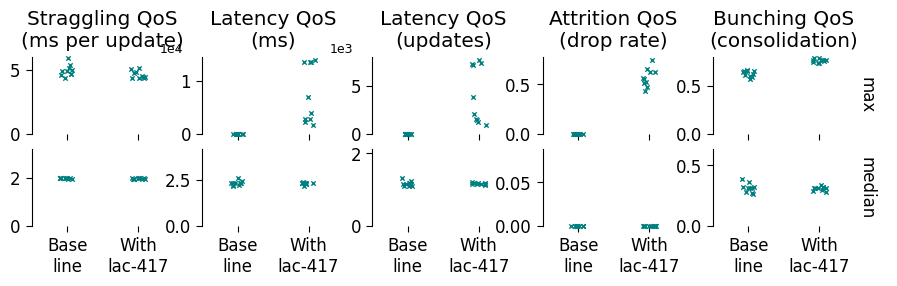

In [ ]:
with tp.teed(
    sns.catplot,
    data=pd.concat([data_max, data_median], ignore_index=True).replace(
        {
            allocation_idx_mapped_title: {
                0: "Base\nline",
                1: "With\nlac-417",
            },
            "Metric": {
                "Simstep Period Outlet (ms)": "Straggling QoS\n(ms per update)",
                "Latency Simsteps Outlet": "Latency QoS\n(updates)",
                "Latency Walltime Outlet (ms)": "Latency QoS\n(ms)",
                "Delivery Clumpiness": "Bunching QoS\n(consolidation)",
                "Delivery Failure Rate": "Attrition QoS\n(drop rate)",
            },
        },
    ),
    col="Metric",
    col_order=[
        "Straggling QoS\n(ms per update)",
        "Latency QoS\n(ms)",
        "Latency QoS\n(updates)",
        "Attrition QoS\n(drop rate)",
        "Bunching QoS\n(consolidation)",
    ],
    row="Kind",
    x=allocation_idx_mapped_title,
    order=["Base\nline", "With\nlac-417"],
    y="Value",
    clip_on=False,
    color="teal",
    kind="strip",
    linewidth=1,
    margin_titles=True,
    marker="x",
    edgecolor="teal",
    s=10,
    sharey=False,
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _g.figure.set_size_inches(9, 2)
    _g.set_titles(col_template="{col_name}", row_template="{row_name}")
    _g.set(ylim=(0, None), xlabel="", ylabel="")
    plt.subplots_adjust(hspace=0.2, wspace=0.2)
    for _ax in _g.axes.flat:
        _ax.ticklabel_format(style="sci", axis="y", scilimits=(-4, 3))
        _ax.yaxis.get_offset_text().set_x(-0.3)
        _ax.yaxis.get_offset_text().set_y(0.5)
        _ax.yaxis.get_offset_text().set_fontsize(9)
    # matplotlib auto-raises a facet's title at draw time to dodge its
    # offset text (columns without offset text keep their titles at the
    # default position, creating a ragged title row); passing an
    # explicit y disables that autoposition so all titles line up
    for _a in _g.axes.flat:
        _a.set_title(_a.title.get_text(), y=1.02)
    for _ax in _g.axes[1, :].flat:
        _ax.set_ylim(1.6 * np.array(_ax.get_ylim()))
    sns.despine(fig=_g.figure, bottom=True)

10 10
10 10
10 10
10 10
10 10
10 10
10 10
10 10
10 10
10 10
teeplots/2026-05-16-lac-417/col=metric+hue=significance+kind=strip+marker=x+row=kind+viz=catplot+x=0-sans-lac-417-1-with-lac-417+y=value+ext=.pdf
teeplots/2026-05-16-lac-417/col=metric+hue=significance+kind=strip+marker=x+row=kind+viz=catplot+x=0-sans-lac-417-1-with-lac-417+y=value+ext=.png


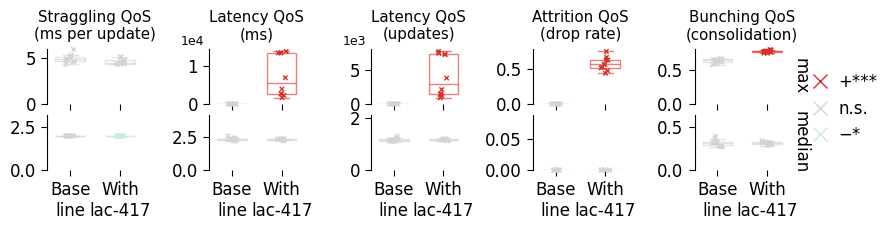

,Metric,Kind,Median Baseline,Median With lac-417,% Change,p-value,Significance
0,Attrition QoS (drop rate),max,0.000000,0.558917,NaN,0.000064,+***
1,Attrition QoS (drop rate),median,0.000000,0.000000,NaN,1.000000,n.s.
2,Bunching QoS (consolidation),max,0.635702,0.766946,20.645485,0.000183,+***
3,Bunching QoS (consolidation),median,0.316903,0.315398,-0.474660,1.000000,n.s.
4,Latency QoS (ms),max,4.559967,5471.012397,119879.198582,0.000183,+***
5,Latency QoS (ms),median,2.313937,2.312360,-0.068156,0.909722,n.s.
6,Latency QoS (updates),max,2.336015,2958.708333,126556.214510,0.000183,+***
7,Latency QoS (updates),median,1.165339,1.170401,0.434341,0.623176,n.s.
8,Straggling QoS (ms per update),max,4.891886,4.471100,-8.601708,0.088973,n.s.
9,Straggling QoS (ms per update),median,1.968575,1.958975,-0.487645,0.045155,−*


In [ ]:
_data_combined = pd.concat(
    [data_max, data_median], ignore_index=True
).replace(
    {
        allocation_idx_mapped_title: {0: "Base\nline", 1: "With\nlac-417"},
        "Metric": {
            "Simstep Period Outlet (ms)": "Straggling QoS\n(ms per update)",
            "Latency Simsteps Outlet": "Latency QoS\n(updates)",
            "Latency Walltime Outlet (ms)": "Latency QoS\n(ms)",
            "Delivery Clumpiness": "Bunching QoS\n(consolidation)",
            "Delivery Failure Rate": "Attrition QoS\n(drop rate)",
        },
    },
)

def _pvalue_to_sig(p, baseline, treatment):
    if p > 0.05:
        return "n.s."
    sign = "+" if np.median(treatment) >= np.median(baseline) else "−"
    if p < 0.001:
        return f"{sign}***"
    elif p < 0.01:
        return f"{sign}**"
    else:
        return f"{sign}*"

_data_combined["Significance"] = "n.s."
_stats_rows = []
for (_metric, _kind), _grp in _data_combined.groupby(["Metric", "Kind"]):
    _baseline = _grp.loc[
        _grp[allocation_idx_mapped_title] == "Base\nline", "Value"
    ].to_numpy()
    _treatment = _grp.loc[
        _grp[allocation_idx_mapped_title] == "With\nlac-417", "Value"
    ].to_numpy()
    print(len(_baseline), len(_treatment))
    _p = np.nan
    try:
        _, _p = scipy_stats.mannwhitneyu(_baseline, _treatment)
        _sig = _pvalue_to_sig(_p, _baseline, _treatment)
    except ValueError:  # all zeros
        _sig = "n.s."

    _mask = (
        (_data_combined["Metric"] == _metric)
        & (_data_combined["Kind"] == _kind)
        & (_data_combined[allocation_idx_mapped_title] == "With\nlac-417")
    )
    _data_combined.loc[_mask, "Significance"] = _sig
    _med_b = np.median(_baseline) if len(_baseline) else np.nan
    _med_t = np.median(_treatment) if len(_treatment) else np.nan
    _pct = (
        (_med_t - _med_b) / _med_b * 100
        if _med_b not in (0, np.nan) and not np.isnan(_med_b)
        else np.nan
    )
    _stats_rows.append(
        {
            "Metric": _metric.replace("\n", " "),
            "Kind": _kind,
            "Median Baseline": _med_b,
            "Median With lac-417": _med_t,
            "% Change": _pct,
            "p-value": _p,
            "Significance": _sig,
        }
    )

_sig_palette = {
    "+***": "#d73027",
    "+**": "#f46d43",
    "+*": "#fdae61",
    "n.s.": "lightgray",
    "−*": "#c7eae5",
    "−**": "#5ab4ac",
    "−***": "#01665e",
}
_hue_order = [
    _s
    for _s in [
        "+***",
        "+**",
        "+*",
        "n.s.",
        "−*",
        "−**",
        "−***",
    ]
    if _s in _data_combined["Significance"].unique()
]
_x_order = ["Base\nline", "With\nlac-417"]

with tp.teed(
    sns.catplot,
    data=_data_combined,
    col="Metric",
    col_order=[
        "Straggling QoS\n(ms per update)",
        "Latency QoS\n(ms)",
        "Latency QoS\n(updates)",
        "Attrition QoS\n(drop rate)",
        "Bunching QoS\n(consolidation)",
    ],
    row="Kind",
    x=allocation_idx_mapped_title,
    order=_x_order,
    y="Value",
    hue="Significance",
    hue_order=_hue_order,
    palette=_sig_palette,
    clip_on=False,
    kind="strip",
    linewidth=1,
    margin_titles=True,
    marker="x",
    s=10,
    sharey=False,
    dodge=False,
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _g.figure.set_size_inches(8.3, 1.36)
    _g.set_titles(col_template="{col_name}", row_template="{row_name}")
    _g.set(ylim=(0, None), xlabel="", ylabel="")
    plt.subplots_adjust(hspace=0.2, wspace=0.7)
    for _ax in _g.axes.flat:
        _ax.ticklabel_format(style="sci", axis="y", scilimits=(-4, 3))
        _ax.yaxis.get_offset_text().set_x(-0.3)
        _ax.yaxis.get_offset_text().set_y(0.5)
        _ax.yaxis.get_offset_text().set_fontsize(9)
        # widen the gap between the "Base line"/"With lac-417" x-tick
        # labels, which otherwise crowd together at this panel's width
        _ax.margins(x=0.1)
    # matplotlib auto-raises a facet's title at draw time to dodge its
    # offset text (columns without offset text keep their titles at the
    # default position, creating a ragged title row); passing an
    # explicit y disables that autoposition so all titles line up
    for _a in _g.axes.flat:
        _a.set_title(
            _a.title.get_text(),
            y=1.02,
            fontsize=_a.title.get_fontsize() * 0.9,
        )
    for _ax in _g.axes[1, :].flat:
        _ax.set_ylim(1.6 * np.array(_ax.get_ylim()))

    # subtle color-matched box plot outlines behind the strip points,
    # with transparent fill so the underlying points stay legible
    for _i, _row_val in enumerate(_g.row_names):
        for _j, _col_val in enumerate(_g.col_names):
            _ax = _g.axes[_i, _j]
            _facet_df = _data_combined[
                (_data_combined["Kind"] == _row_val)
                & (_data_combined["Metric"] == _col_val)
            ]
            for _k, _xval in enumerate(_x_order):
                _facet_x_df = _facet_df[
                    _facet_df[allocation_idx_mapped_title] == _xval
                ]
                _vals = _facet_x_df["Value"].dropna()
                if _vals.empty:
                    continue
                _box_color = _sig_palette[
                    _facet_x_df["Significance"].iloc[0]
                ]
                _bp = _ax.boxplot(
                    _vals,
                    positions=[_k],
                    widths=0.6,
                    patch_artist=True,
                    showfliers=False,
                    manage_ticks=False,
                    zorder=0.5,
                )
                for _part in ("boxes", "whiskers", "caps", "medians"):
                    for _artist in _bp[_part]:
                        _artist.set_color(_box_color)
                        _artist.set_alpha(0.6)
                        _artist.set_linewidth(1)
                for _box in _bp["boxes"]:
                    _box.set_facecolor("none")

    sns.despine(fig=_g.figure, bottom=True)
    sns.move_legend(
        _g,
        loc="center right",
        bbox_to_anchor=(1.04, 0.5),
        frameon=False,
        title=None,
        markerscale=3,
        handletextpad=0.1,
    )

stats_df = pd.DataFrame(_stats_rows)
stats_df